### Импортируем необходимые библиотеки

In [2]:
import re
import math
import random
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.nn import Module
from torch.utils.data import DataLoader, Dataset
from sklearn.manifold import TSNE

### 1. В качестве текста взяты первые 20 000 слов романа "Властелин колец" на английском языке

### 2 - 4. Считываем и обрабатываем текст. Создаем необходимые словари
Удаляем служебные символы, цифры и знаки препинания, приводим к нижнему регистру, подсчитываем частоту слов и создаем словари word2idx и idx2word.

In [3]:
token_frequency_dict = dict()
word2idx_dict = dict()
idx2word_dict = dict()
index_counter = 0
text = list()

with open('text.txt', mode='r', encoding='utf-8') as f:
    line = f.readline()
    while line:
        # С помощью регулярных выражений удаляем все ненужные символы, затем приводим к нижнему регистру и разбиваем по словам
        line = re.sub(r'[\d!?\.,;:"\(\)\'\-\’]', '', line).lower().strip().split()
        for token in line:
            try:
                token_frequency_dict[token] += 1
            except KeyError:
                token_frequency_dict[token] = 1
                word2idx_dict[token] = index_counter
                idx2word_dict[index_counter] = token
                index_counter += 1
            text.append(token)
        line = f.readline()

In [5]:
print("Первые 50 слов в тексте:\n", text[:50])
print("\nСамые частые слова в тексте:\n", sorted(token_frequency_dict.items(), key=lambda item: item[1], reverse=True)[:50])
print("\nСловарь word2idx:\n", word2idx_dict)
print("\nСловарь idx2word:\n", idx2word_dict)
print("\nКоличество уникальных слов в тексте: " + str(len(word2idx_dict)))

Первые 50 слов в тексте:
 ['concerning', 'hobbits', 'this', 'book', 'is', 'largely', 'concerned', 'with', 'hobbits', 'and', 'from', 'its', 'pages', 'a', 'reader', 'may', 'discover', 'much', 'of', 'their', 'character', 'and', 'a', 'little', 'of', 'their', 'history', 'further', 'information', 'will', 'also', 'be', 'found', 'in', 'the', 'selection', 'from', 'the', 'red', 'book', 'of', 'westmarch', 'that', 'has', 'already', 'been', 'published', 'under', 'the', 'title']

Самые частые слова в тексте:
 [('the', 1201), ('and', 844), ('of', 633), ('to', 416), ('in', 385), ('a', 367), ('he', 337), ('was', 308), ('it', 292), ('that', 267), ('they', 216), ('i', 210), ('his', 205), ('were', 193), ('had', 186), ('but', 177), ('as', 159), ('for', 157), ('at', 155), ('with', 136), ('you', 128), ('on', 124), ('bilbo', 122), ('not', 120), ('all', 111), ('said', 110), ('there', 104), ('is', 92), ('their', 90), ('or', 89), ('from', 88), ('hobbits', 87), ('frodo', 86), ('him', 82), ('by', 81), ('old', 72),

### 5. Проводим субсемплирование

Для субсемплирования используется следующая формула из статьи о [Skip-gram](https://arxiv.org/pdf/1310.4546)

P(wi) = 1 - sqrt(t/f(wi))

P(wi) - вероятность удаления слова wi из последовательности;
t - пороговое значение (threshold), заданое пользователем;
f(wi) - относительная частота слова в тексте

In [ ]:
# Создаем отдельный словарь для субсемплированного текста
token_relative_frequency_dict = dict()
for token in token_frequency_dict:
    token_relative_frequency_dict[token] = token_frequency_dict[token] / len(text)

subsampled_frequency_dict = token_frequency_dict
threshold = 1e-5
text_len = len(text)

# Проводим субсемплирование в соответствии с формулой
for token in text:
    if subsampled_frequency_dict[token] >= 50:
        frequency = token_relative_frequency_dict[token]
        p = 1 - math.sqrt(threshold / frequency)

        if random.random() >= p:
            text.remove(token)
            subsampled_frequency_dict[token] -= 1

print('Частотный словарь после субсемплирования')
print(sorted(subsampled_frequency_dict.items(), key=lambda item: item[1], reverse=True)[:50])

Частотный словарь после субсемплирования
[('the', 1187), ('and', 830), ('of', 616), ('to', 408), ('in', 379), ('a', 361), ('he', 329), ('was', 299), ('it', 284), ('that', 258), ('they', 206), ('i', 200), ('his', 194), ('were', 188), ('had', 183), ('but', 175), ('as', 157), ('at', 150), ('for', 150), ('with', 133), ('you', 124), ('bilbo', 118), ('on', 118), ('not', 116), ('said', 107), ('all', 106), ('there', 104), ('is', 87), ('their', 87), ('or', 87), ('from', 86), ('hobbits', 84), ('frodo', 83), ('by', 77), ('him', 77), ('old', 71), ('more', 67), ('be', 65), ('have', 65), ('this', 60), ('shire', 57), ('been', 56), ('no', 56), ('one', 56), ('them', 55), ('up', 55), ('out', 54), ('long', 53), ('an', 49), ('many', 49), ('if', 49), ('gandalf', 49), ('about', 48), ('than', 48), ('now', 48), ('my', 48), ('some', 46), ('very', 46), ('time', 44), ('so', 44), ('end', 44), ('when', 43), ('after', 43), ('still', 43), ('ring', 43), ('are', 42), ('only', 42), ('did', 41), ('even', 40), ('then', 3

### 6 - 7. Создаем класс Word2VecDataset и реализуем в нем создание пар слов скользящим окном

In [34]:
class Word2VecDataset(Dataset):
    def __init__(self, text: list, freq_dict: dict, word2idx: dict, idx2word: dict):
        self.text = text
        self.freq_dict = freq_dict
        self.word2idx = word2idx
        self.idx2word = idx2word

        self.text_len = len(self.text)
        self.pairs = self.generate_pairs(4)

    def generate_pairs(self, window_size: int):
        """Генерирует пары 'центральное слово - контекстное слово' с помощью скользящего окна заданного размера"""
        pairs = list()
        for i in range(self.text_len):
            center_word_idx = self.word2idx[self.text[i]]

            # Определяем границы скользящего окна
            window_start = max(0, i - window_size)
            window_end = min(self.text_len, i + window_size + 1)

            for j in range(window_start, window_end):
                if j == i:
                    continue
                context_word_idx = self.word2idx[self.text[j]]
                pairs.append((center_word_idx, context_word_idx))

        return pairs
    

    def __len__(self) -> int:
        """Возвращает количество пар в датасете."""
        return len(self.pairs)
    
    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Возвращает пару (центральное слово, контекстное слово) в виде тензоров.
        
        Args:
            idx: индекс элемента
            
        Returns:
            кортеж (center_word, context_word) в виде тензоров типа LongTensor
        """
        center_idx, context_idx = self.pairs[idx]
        
        return (
            torch.tensor(center_idx, dtype=torch.long),
            torch.tensor(context_idx, dtype=torch.long)
        )


### 8. Создаем датасет с помощью Word2VecDataset и оборачиваем его в DataLoader

In [35]:
dataset = Word2VecDataset(text, subsampled_frequency_dict, word2idx_dict, idx2word_dict)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

### 8 - 10. Реализуем модели на основе Full Softmax и Negative Samples

### Full Softmax

In [36]:
class Word2VecFullSoftmax(nn.Module):
    def __init__(self, vocab_size: int, word2idx: dict, embedding_dim: int = 100):
        """
        Args:
            vocab_size: размер словаря (V)
            embedding_dim: размерность эмбеддингов
        """
        super().__init__()
        
        # 1. Слой эмбеддингов для центральных слов (входная матрица)
        self.embedding_center = nn.Embedding(vocab_size, embedding_dim)
        
        # 2. Линейный слой для проекции на размер словаря (выходная матрица)
        self.output_projection = nn.Linear(embedding_dim, vocab_size)

        # Словарь word2idx (непосредственно в модели не задействуется, используется в функции по нахождению ближайших слов)
        self.word2idx = word2idx
        
        # Инициализация весов
        self._init_weights()
    
    def _init_weights(self):
        """Инициализация весов модели"""
        nn.init.uniform_(self.embedding_center.weight, -0.5/self.embedding_center.embedding_dim, 0.5/self.embedding_center.embedding_dim)
        nn.init.uniform_(self.output_projection.weight, -0.5/self.output_projection.in_features, 0.5/self.output_projection.in_features)
        nn.init.zeros_(self.output_projection.bias)
    
    def forward(self, center_words: torch.Tensor) -> torch.Tensor:
        """
        Forward pass модели
        
        Args:
            center_words: тензор индексов центральных слов (batch_size)
            
        Returns:
            логиты размерности (batch_size, vocab_size)
        """
        # Получаем эмбеддинги для центральных слов
        # shape: (batch_size, embedding_dim)
        center_embeds = self.embedding_center(center_words)
        
        # Проецируем на размер словаря
        # shape: (batch_size, vocab_size)
        logits = self.output_projection(center_embeds)
        
        return logits
    
    def get_embeddings_matrix(self):
        """Возвращает матрицу эмбеддингов всех слов"""
        return self.embedding_center.weight.detach().cpu().numpy()

In [37]:
def train_full_softmax(model, dataloader, criterion, optimizer, num_epochs=5):
    model.train()

    loss_history_full_softmax = []
    
    for epoch in range(num_epochs):
        total_loss = 0
        
        for batch_idx, (center_words, context_words) in enumerate(dataloader):
            # Обнуляем градиенты
            optimizer.zero_grad()
            
            # Forward pass
            logits = model(center_words)  # shape: (batch_size, vocab_size)
            
            # Вычисляем loss
            # CrossEntropyLoss ожидает логиты (batch_size, vocab_size) и целевые индексы (batch_size)
            loss = criterion(logits, context_words)
            
            # Backward pass
            loss.backward()
            
            # Обновляем веса
            optimizer.step()
            
            total_loss += loss.item()
            
            if batch_idx % 10 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx}], Loss: {loss.item():.4f}')
        avg_loss = total_loss / len(dataloader)

        loss_history_full_softmax.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}] completed, Average Loss: {avg_loss:.4f}')
    
    return model, loss_history_full_softmax

Обучение FullSoftmax

In [38]:
vocab_size = len(subsampled_frequency_dict)
embedding_dim = 100

model_full_softmax = Word2VecFullSoftmax(vocab_size, word2idx_dict, embedding_dim)

criterion = nn.CrossEntropyLoss()  # аппаратно реализует Softmax по всему словарю
optimizer = optim.Adam(model_full_softmax.parameters(), lr=0.001)

print("Начинаем обучение модели...")
trained_model, loss_history_full_softmax = train_full_softmax(model_full_softmax, dataloader, criterion, optimizer, num_epochs=20)


Начинаем обучение модели...
Epoch [1/20], Batch [0], Loss: 8.1044
Epoch [1/20], Batch [10], Loss: 8.0960
Epoch [1/20], Batch [20], Loss: 8.0819
Epoch [1/20], Batch [30], Loss: 8.0540
Epoch [1/20], Batch [40], Loss: 8.0169
Epoch [1/20], Batch [50], Loss: 7.9846
Epoch [1/20], Batch [60], Loss: 7.9335
Epoch [1/20], Batch [70], Loss: 7.8470
Epoch [1/20], Batch [80], Loss: 7.7520
Epoch [1/20], Batch [90], Loss: 7.6432
Epoch [1/20], Batch [100], Loss: 7.6165
Epoch [1/20], Batch [110], Loss: 7.4424
Epoch [1/20], Batch [120], Loss: 7.3319
Epoch [1/20], Batch [130], Loss: 7.2053
Epoch [1/20], Batch [140], Loss: 7.3241
Epoch [1/20], Batch [150], Loss: 7.1562
Epoch [1/20], Batch [160], Loss: 7.0872
Epoch [1/20], Batch [170], Loss: 6.8863
Epoch [1/20], Batch [180], Loss: 6.8828
Epoch [1/20], Batch [190], Loss: 6.8873
Epoch [1/20], Batch [200], Loss: 7.0450
Epoch [1/20], Batch [210], Loss: 6.8880
Epoch [1/20], Batch [220], Loss: 6.9508
Epoch [1/20], Batch [230], Loss: 7.0700
Epoch [1/20], Batch [24

### Negative Sampling

In [39]:
class NegativeSamplingWord2Vec(nn.Module):
    """
    Модель Word2Vec с Negative Sampling
    
    Архитектура содержит два слоя эмбеддингов:
    - embedding_center: для центральных слов
    - embedding_context: для контекстных и шумовых слов
    """
    
    def __init__(self, vocab_size: int, embedding_dim: int, freq_dict: dict, word2idx: dict):
        """
        Args:
            vocab_size: размер словаря
            embedding_dim: размерность эмбеддингов
            freq_dict: частотный словарь слов
            word2idx: словарь соответствия слов и индексов
        """
        super().__init__()
        
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.word2idx = word2idx
        
        # 2. Создаем два слоя nn.Embedding для центральных и контекстных/шумовых слов
        self.embedding_center = nn.Embedding(vocab_size, embedding_dim)
        self.embedding_context = nn.Embedding(vocab_size, embedding_dim)
        
        # 1. Вычисляем вероятностное распределение для выбора шумовых слов
        self.noise_distribution = self._calculate_noise_distribution(freq_dict)
        
        # Инициализация весов
        self._init_weights()
        
    def _init_weights(self):
        """Инициализация весов эмбеддингов"""
        init_range = 0.5 / self.embedding_dim
        nn.init.uniform_(self.embedding_center.weight, -init_range, init_range)
        nn.init.uniform_(self.embedding_context.weight, -init_range, init_range)
        
    def _calculate_noise_distribution(self, freq_dict: dict) -> torch.Tensor:
        """
        Вычисляет вероятностное распределение для выбора шумовых слов.
        Частоты слов возводятся в степень 0.75 и нормализуются.
        
        Args:
            freq_dict: частотный словарь слов
            
        Returns:
            тензор с вероятностями для каждого слова в словаре
        """
        # Получаем частоты для всех слов в порядке их индексов
        freqs = torch.zeros(self.vocab_size)
        for word, idx in self.word2idx.items():
            freqs[idx] = freq_dict[word]
        
        # Возводим частоты в степень 0.75
        freqs_powered = freqs ** 0.75
        
        # Нормализуем для получения вероятностей
        noise_dist = freqs_powered / freqs_powered.sum()
        
        return noise_dist
    
    def sample_negative_examples(self, batch_size: int, num_negatives: int, positive_context: torch.Tensor):
        """
        Сэмплирует негативные примеры из распределения шумовых слов.
        
        Args:
            batch_size: размер батча
            num_negatives: количество негативных примеров на каждую положительную пару
            positive_context: тензор с индексами положительных контекстных слов (batch_size,)
            
        Returns:
            тензор с индексами негативных примеров размером (batch_size, num_negatives)
        """
        # Сэмплируем негативные примеры из распределения
        # Умножаем на batch_size * num_negatives для получения достаточного количества примеров
        num_samples = batch_size * num_negatives
        
        # Сэмплируем с заменой
        negative_samples = torch.multinomial(
            self.noise_distribution, 
            num_samples, 
            replacement=True
        )
        
        # Изменяем форму на (batch_size, num_negatives)
        negative_samples = negative_samples.view(batch_size, num_negatives)
        
        # Важно: исключаем случаи, когда негативный пример совпадает с положительным контекстом
        # Для простоты в этой реализации мы просто заменяем совпадения
        for i in range(batch_size):
            for j in range(num_negatives):
                if negative_samples[i, j] == positive_context[i]:
                    # Если совпало, сэмплируем новое значение
                    negative_samples[i, j] = torch.multinomial(
                        self.noise_distribution, 
                        1, 
                        replacement=True
                    ).item()
        
        return negative_samples
    
    def forward(self, center_words: torch.Tensor, context_words: torch.Tensor, num_negatives: int = 5):
        """
        Вычисляет значение функции потерь для Negative Sampling.
        
        Args:
            center_words: тензор с индексами центральных слов (batch_size,)
            context_words: тензор с индексами контекстных слов (batch_size,)
            num_negatives: количество негативных примеров на каждую пару
            
        Returns:
            значение функции потерь (скалярный тензор)
        """
        batch_size = center_words.shape[0]
        
        # Получаем эмбеддинги центральных слов (batch_size, embedding_dim)
        center_embeddings = self.embedding_center(center_words)
        
        # Получаем эмбеддинги положительных контекстных слов (batch_size, embedding_dim)
        positive_context_embeddings = self.embedding_context(context_words)
        
        # Вычисляем сходство для положительных пар (batch_size,)
        positive_scores = torch.sum(center_embeddings * positive_context_embeddings, dim=1)
        
        # Сэмплируем негативные примеры
        negative_samples = self.sample_negative_examples(batch_size, num_negatives, context_words)
        
        # Получаем эмбеддинги негативных примеров (batch_size, num_negatives, embedding_dim)
        negative_embeddings = self.embedding_context(negative_samples)
        
        # Вычисляем сходство для негативных пар
        # center_embeddings: (batch_size, embedding_dim) -> (batch_size, 1, embedding_dim)
        # negative_embeddings: (batch_size, num_negatives, embedding_dim)
        # Результат: (batch_size, num_negatives)
        center_embeddings_expanded = center_embeddings.unsqueeze(1)
        negative_scores = torch.sum(center_embeddings_expanded * negative_embeddings, dim=2)
        
        # 3. Вычисляем функцию потерь
        # Используем логистическую функцию потерь (binary cross-entropy)
        
        # Для положительных пар
        positive_loss = -F.logsigmoid(positive_scores)
        
        # Для негативных пар
        negative_loss = -F.logsigmoid(-negative_scores)
        
        # Суммируем потери для негативных примеров
        negative_loss_sum = negative_loss.sum(dim=1)
        
        # Общая потеря для каждого примера в батче
        total_loss_per_example = positive_loss + negative_loss_sum
        
        # Усредняем по батчу
        total_loss = total_loss_per_example.mean()
        
        return total_loss
    
    def get_embeddings_matrix(self):
        """Возвращает матрицу эмбеддингов всех слов"""
        return self.embedding_center.weight.detach().cpu().numpy()

In [40]:
def train_negative_samples(model, dataloader, optimizer, num_negatives):
    model.train()
    total_loss = 0
    
    for batch_idx, (center_words, context_words) in enumerate(dataloader):
        optimizer.zero_grad()
        
        # Forward pass
        loss = model(center_words, context_words, num_negatives)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        if batch_idx % 10 == 0:
            print(f'Batch {batch_idx}, Loss: {loss.item():.4f}')
    
    return total_loss / len(dataloader)

Обучение Negative Samples

In [41]:
embedding_dim = 100
vocab_size = len(subsampled_frequency_dict)

model_neg_samples = NegativeSamplingWord2Vec(vocab_size, embedding_dim, subsampled_frequency_dict, word2idx_dict)

criterion = nn.CrossEntropyLoss()  # аппаратно реализует Softmax по всему словарю
optimizer = optim.Adam(model_neg_samples.parameters(), lr=0.001)

num_epochs = 20
num_negatives = 6

loss_history_neg_samples = []

print("Начало обучения...")
for epoch in range(num_epochs):
    avg_loss = train_negative_samples(model_neg_samples, dataloader, optimizer, num_negatives)
    loss_history_neg_samples.append(avg_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}')

Начало обучения...
Batch 0, Loss: 4.8520
Batch 10, Loss: 4.8520
Batch 20, Loss: 4.8507
Batch 30, Loss: 4.8458
Batch 40, Loss: 4.8325
Batch 50, Loss: 4.8043
Batch 60, Loss: 4.7582
Batch 70, Loss: 4.7169
Batch 80, Loss: 4.6316
Batch 90, Loss: 4.5747
Batch 100, Loss: 4.4074
Batch 110, Loss: 4.3635
Batch 120, Loss: 4.1988
Batch 130, Loss: 4.1889
Batch 140, Loss: 4.0956
Batch 150, Loss: 4.1058
Batch 160, Loss: 3.8083
Batch 170, Loss: 3.8376
Batch 180, Loss: 3.7711
Batch 190, Loss: 3.7048
Batch 200, Loss: 3.7901
Batch 210, Loss: 3.6648
Batch 220, Loss: 3.7193
Batch 230, Loss: 3.6513
Batch 240, Loss: 3.4977
Batch 250, Loss: 3.4297
Batch 260, Loss: 3.3248
Batch 270, Loss: 3.4434
Batch 280, Loss: 3.3515
Batch 290, Loss: 3.3083
Batch 300, Loss: 3.2867
Batch 310, Loss: 3.3167
Batch 320, Loss: 3.2698
Batch 330, Loss: 3.3444
Batch 340, Loss: 3.3485
Batch 350, Loss: 3.1744
Batch 360, Loss: 3.2275
Batch 370, Loss: 3.2703
Batch 380, Loss: 3.2323
Batch 390, Loss: 3.1921
Batch 400, Loss: 3.1211
Batch 41

### 11 - 12. Реализуем функцию нахождения top-n ближайщих слов по косинусному сходству

In [42]:
def find_closest_words(model, target_word, n=5):
    """
    Находит n ближайших слов к заданному слову по косинусному сходству
    """
    target_idx = model.word2idx[target_word]
    target_embedding = model.embedding_center(torch.tensor(target_idx))
    
    # Вычисляем косинусное сходство со всеми словами
    all_embeddings = model.embedding_center.weight # Извлекаем матрицу весов входного слоя
    similarities = F.cosine_similarity(target_embedding.unsqueeze(0), all_embeddings)
    
    # Получаем индексы наиболее похожих слов (исключая само слово)
    top_indices = similarities.argsort(descending=True)[1:n+1]
    
    # Преобразуем индексы в слова
    idx2word = {idx: word for word, idx in model.word2idx.items()}
    closest_words = [idx2word[idx.item()] for idx in top_indices]
    
    return closest_words

Negative Samples

In [43]:
print("Ближайшие слова к слову hobbit:\n", find_closest_words(model_neg_samples, "hobbit"))
print("\nБлижайшие слова к слову shire:\n", find_closest_words(model_neg_samples, "shire"))
print("\nБлижайшие слова к слову gandalf:\n", find_closest_words(model_neg_samples, "gandalf"))

Ближайшие слова к слову hobbit:
 ['recover', 'elderly', 'disbelieved', 'chapters', 'loved']

Ближайшие слова к слову shire:
 ['introduction', 'extensive', 'showing', 'herblore', 'materials']

Ближайшие слова к слову gandalf:
 ['eh', 'sorry', '‘known', 'shaking', '‘yes']


Full Softmax

In [44]:
print("Ближайшие слова к слову hobbit:\n", find_closest_words(model_full_softmax, "hobbit"))
print("\nБлижайшие слова к слову shire:\n", find_closest_words(model_full_softmax, "shire"))
print("\nБлижайшие слова к слову gandalf:\n", find_closest_words(model_full_softmax, "gandalf"))

Ближайшие слова к слову hobbit:
 ['chapters', 'recover', 'title', 'disbelieved', 'murder']

Ближайшие слова к слову shire:
 ['herblore', 'introduction', 'remembered', 'within', 'elftowers']

Ближайшие слова к слову gandalf:
 ['eh', 'shaking', 'sorry', '‘known', '‘we']


### График потерь при обучении

In [45]:
print(len(loss_history_neg_samples))
print(len(loss_history_full_softmax))

20
20


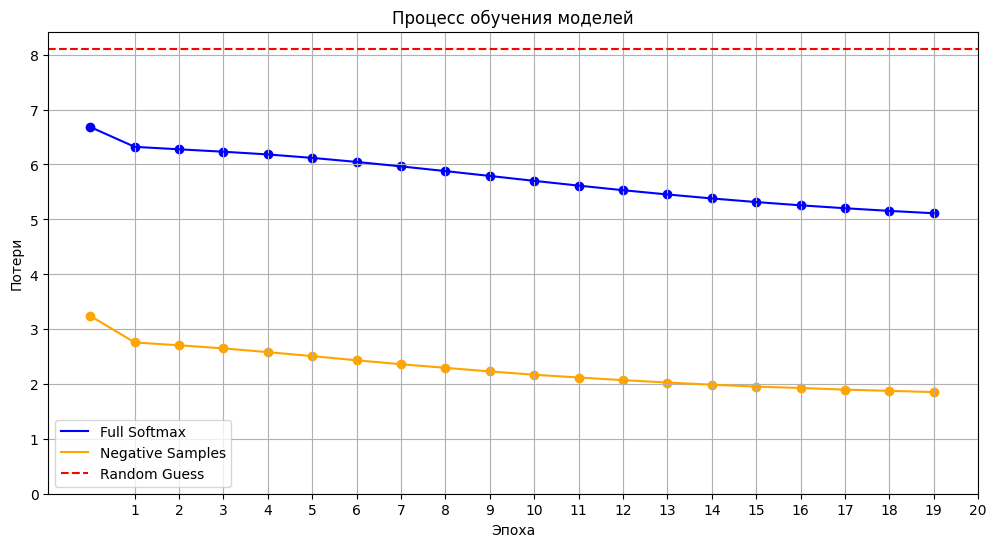

In [46]:
def plot_training_progress(losses_full_softmax, losses_neg_samples):
    num_epochs_full_softmax = len(losses_full_softmax)
    num_epochs_neg_samples = len(losses_neg_samples)

    plt.figure(figsize=(12, 6))
    plt.plot(losses_full_softmax, color='blue', label='Full Softmax')
    plt.plot(losses_neg_samples, color='orange', label='Negative Samples')
    plt.axhline(y=math.log(len(word2idx_dict)), color='r', linestyle='--', label='Random Guess')

    plt.scatter(range(num_epochs_full_softmax), loss_history_full_softmax, color='blue', marker='o')
    plt.scatter(range(num_epochs_neg_samples), loss_history_neg_samples, color='orange', marker='o')

    plt.xticks(range(1, max(num_epochs_full_softmax, num_epochs_neg_samples) + 1))
    plt.yticks(range(math.ceil(math.log(len(word2idx_dict)))))
    
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.title('Процесс обучения моделей')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_progress(loss_history_full_softmax, loss_history_neg_samples)

### 13 - 14. Класс для сжатия векторов эмбеддингов с помощью t-SNE и их последующей визуализации

In [47]:
class Word2VecVisualizer:
    """
    Класс для визуализации эмбеддингов слов с помощью t-SNE
    """
    
    def __init__(self, model, word2idx, idx2word):
        self.model = model
        self.word2idx = word2idx
        self.idx2word = idx2word
        self.vocab_size = len(word2idx)
        
    def plot_tsne(self, perplexity=30, max_iter=2000, 
                  figsize=(15, 10)):
        """
        Визуализирует эмбеддинги слов в 2D с помощью t-SNE
        
        Args:
            perplexity: параметр перплексии для t-SNE (обычно 5-50)
            n_iter: количество итераций оптимизации
            figsize: размер графика
        """
        # Получаем матрицу эмбеддингов
        embeddings = self.model.get_embeddings_matrix()
        
        print(f"Размерность исходных эмбеддингов: {embeddings.shape}")
        
        # Применяем t-SNE для понижения размерности до 2D
        print("Применяем t-SNE...")
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            max_iter=max_iter,
            verbose=1
        )
        
        embeddings_2d = tsne.fit_transform(embeddings)
        print(f"Размерность после t-SNE: {embeddings_2d.shape}")
        
        # Создаем визуализацию
        self._create_plot(embeddings_2d[:50], figsize)
        
        return embeddings_2d
    
    def _create_plot(self, embeddings_2d, figsize=(15, 10)):
        """
        Создает детальную визуализацию с подписями
        """
        plt.figure(figsize=figsize)
        
        # Создаем цветовую карту на основе частоты слов
        colors = plt.cm.viridis(np.linspace(0, 1, len(embeddings_2d)))
        
        # Рисуем точки
        scatter = plt.scatter(
            embeddings_2d[:, 0], 
            embeddings_2d[:, 1],
            c=colors,
            alpha=0.7,
            s=200,
            edgecolors='black',
            linewidth=1
        )
        
        # Добавляем подписи для всех слов
        for i, (x, y) in enumerate(embeddings_2d):
            word = self.idx2word[i]
            
            # Определяем стиль подписи
            plt.annotate(
                word,
                (x, y),
                fontsize=11,
                alpha=0.8,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7)
            )
        
        # Настройки графика
        plt.title('Визуализация эмбеддингов первых 50 слов с помощью t-SNE', fontsize=18, fontweight='bold')
        plt.xlabel('t-SNE компонента 1', fontsize=14)
        plt.ylabel('t-SNE компонента 2', fontsize=14)
        plt.grid(True, alpha=0.3)
        
        # Добавляем цветовую шкалу
        cbar = plt.colorbar(scatter)
        cbar.set_label('Индекс слова', fontsize=12)
        
        plt.tight_layout()
        plt.show()

Визуализация для Negative Samples

Размерность исходных эмбеддингов: (3309, 100)
Применяем t-SNE...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3309 samples in 0.000s...
[t-SNE] Computed neighbors for 3309 samples in 1.730s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3309
[t-SNE] Computed conditional probabilities for sample 2000 / 3309
[t-SNE] Computed conditional probabilities for sample 3000 / 3309
[t-SNE] Computed conditional probabilities for sample 3309 / 3309
[t-SNE] Mean sigma: 1.422152
[t-SNE] KL divergence after 50 iterations with early exaggeration: 80.515625
[t-SNE] KL divergence after 3000 iterations: 2.419940
Размерность после t-SNE: (3309, 2)


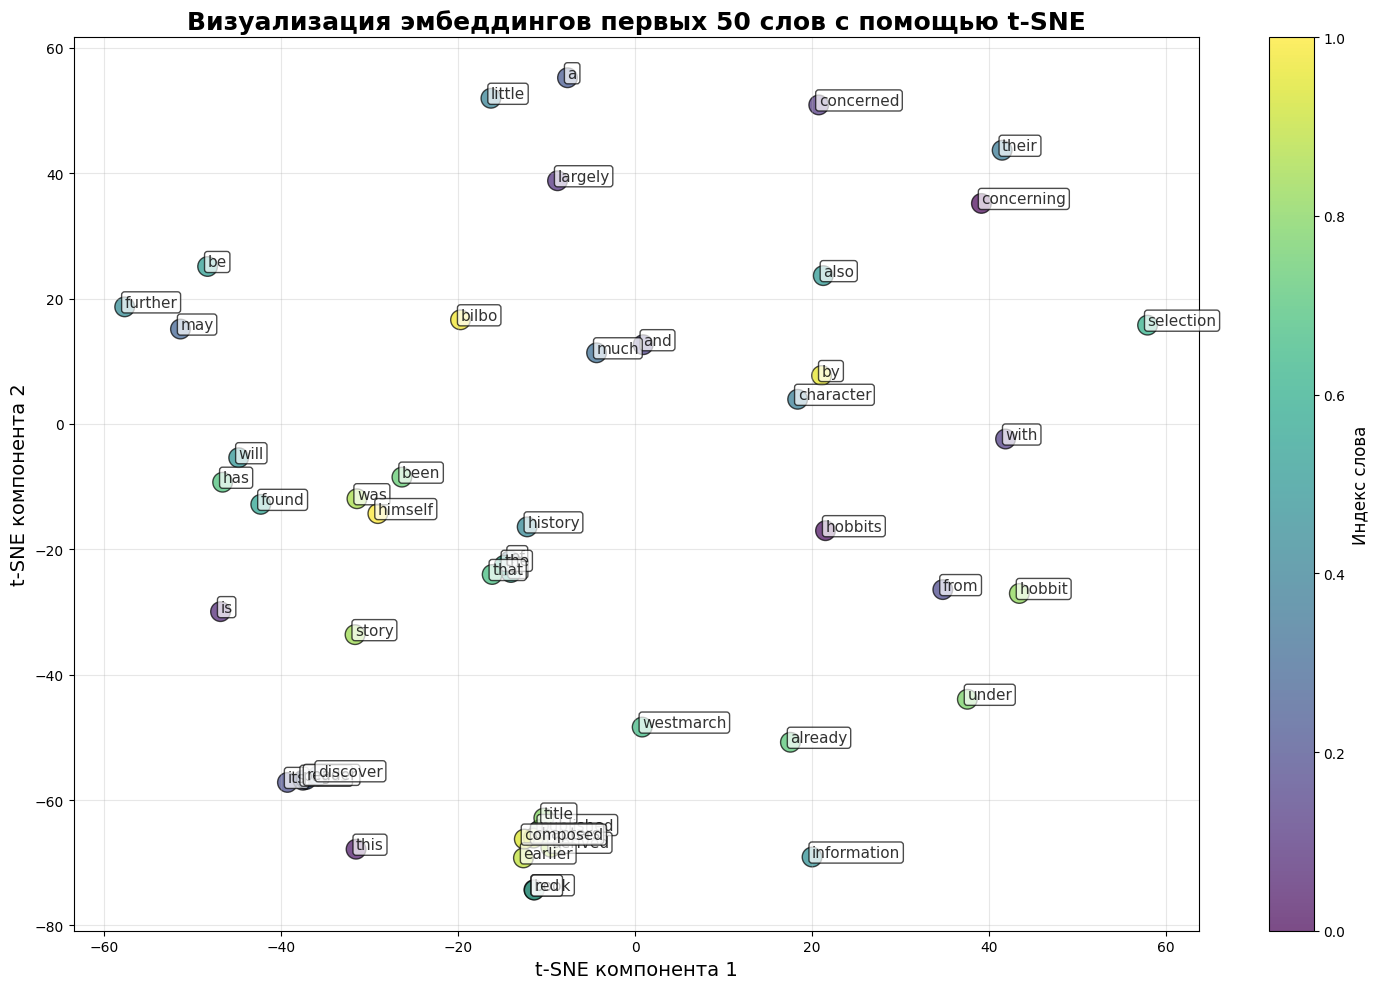

In [48]:
neg_samples_visualizer = Word2VecVisualizer(model_neg_samples, word2idx_dict, idx2word_dict)

embeddings_2d = neg_samples_visualizer.plot_tsne(
    perplexity=40,
    max_iter=3000
)

Визуализация для Full Softmax

Размерность исходных эмбеддингов: (3309, 100)
Применяем t-SNE...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3309 samples in 0.000s...
[t-SNE] Computed neighbors for 3309 samples in 0.137s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3309
[t-SNE] Computed conditional probabilities for sample 2000 / 3309
[t-SNE] Computed conditional probabilities for sample 3000 / 3309
[t-SNE] Computed conditional probabilities for sample 3309 / 3309
[t-SNE] Mean sigma: 1.142004
[t-SNE] KL divergence after 200 iterations with early exaggeration: 79.920090
[t-SNE] KL divergence after 3000 iterations: 2.311709
Размерность после t-SNE: (3309, 2)


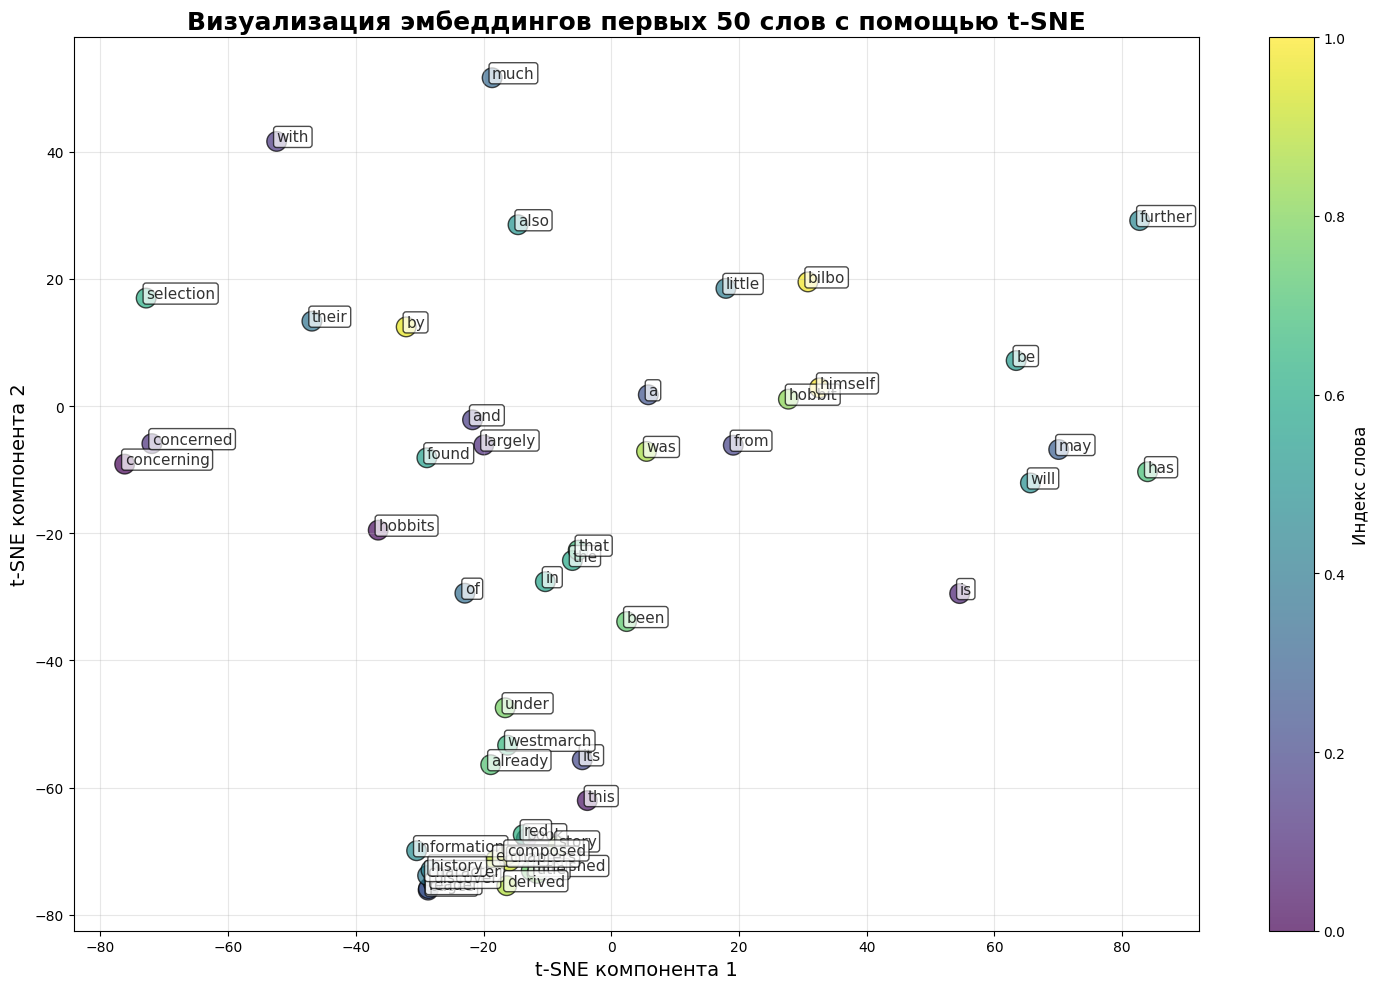

In [49]:
full_softmax_visualizer = Word2VecVisualizer(model_full_softmax, word2idx_dict, idx2word_dict)

embeddings_2d = full_softmax_visualizer.plot_tsne(
    perplexity=40,
    max_iter=3000
)